In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Load data and models
df       = pd.read_csv('../data/featured_aqi.csv', parse_dates=['Date'])
X_test   = pd.read_csv('../data/X_test.csv')
y_test   = pd.read_csv('../data/y_test.csv').squeeze()
rf_model = joblib.load('../models/random_forest.pkl')
feature_cols = joblib.load('../models/feature_cols.pkl')

rf_preds = rf_model.predict(X_test)
test_df  = df[df['Year'] == 2020].copy().reset_index(drop=True)
test_df['RF_Predicted'] = rf_preds

print("Everything loaded ✓")

Everything loaded ✓


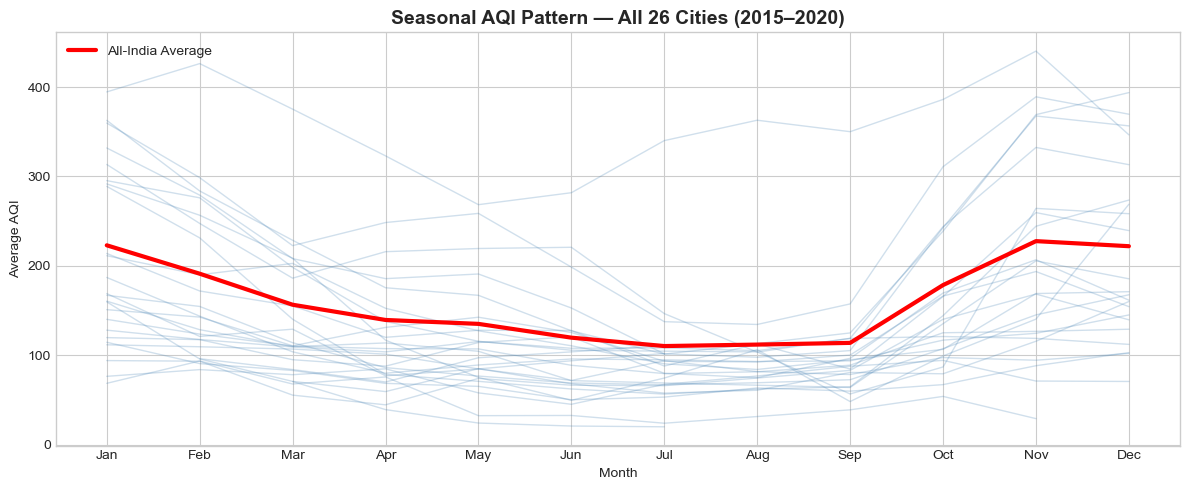

Plot 1 saved ✓


In [2]:
monthly_avg = df.groupby(['Month', 'City'])['AQI'].mean().reset_index()
monthly_all = df.groupby('Month')['AQI'].mean()

plt.figure(figsize=(12, 5))
for city in df['City'].unique():
    city_data = monthly_avg[monthly_avg['City'] == city]
    plt.plot(city_data['Month'], city_data['AQI'],
             alpha=0.25, color='steelblue', linewidth=1)

plt.plot(monthly_all.index, monthly_all.values,
         color='red', linewidth=3, label='All-India Average', zorder=5)

plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.title('Seasonal AQI Pattern — All 26 Cities (2015–2020)', 
          fontweight='bold', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Average AQI')
plt.legend()
plt.tight_layout()
plt.savefig('../visualizations/08_seasonal_pattern.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 1 saved ✓")

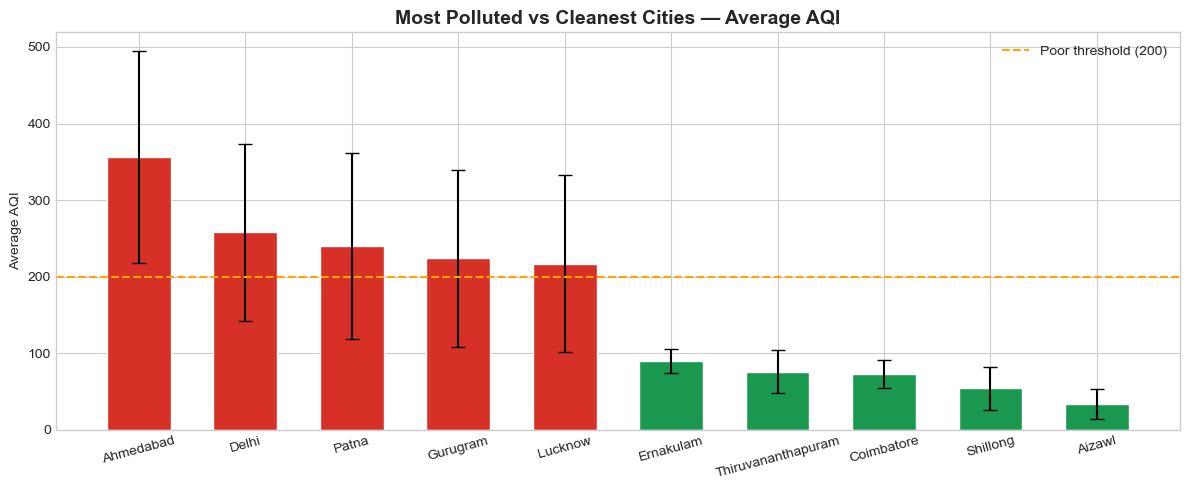

Plot 2 saved ✓


In [3]:
city_stats = df.groupby('City')['AQI'].agg(['mean','std']).round(1)
city_stats.columns = ['Mean_AQI', 'Std_AQI']
city_stats = city_stats.sort_values('Mean_AQI', ascending=False)

top5    = city_stats.head(5)
bottom5 = city_stats.tail(5)
compare = pd.concat([top5, bottom5])

colors = ['#d73027']*5 + ['#1a9850']*5

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(compare.index, compare['Mean_AQI'], 
              color=colors, edgecolor='white', width=0.6)
ax.errorbar(range(len(compare)), compare['Mean_AQI'],
            yerr=compare['Std_AQI'], fmt='none', 
            color='black', capsize=5, linewidth=1.5)
ax.set_title('Most Polluted vs Cleanest Cities — Average AQI', 
             fontweight='bold', fontsize=14)
ax.set_ylabel('Average AQI')
ax.axhline(200, color='orange', linestyle='--', 
           linewidth=1.5, label='Poor threshold (200)')
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../visualizations/09_city_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 2 saved ✓")

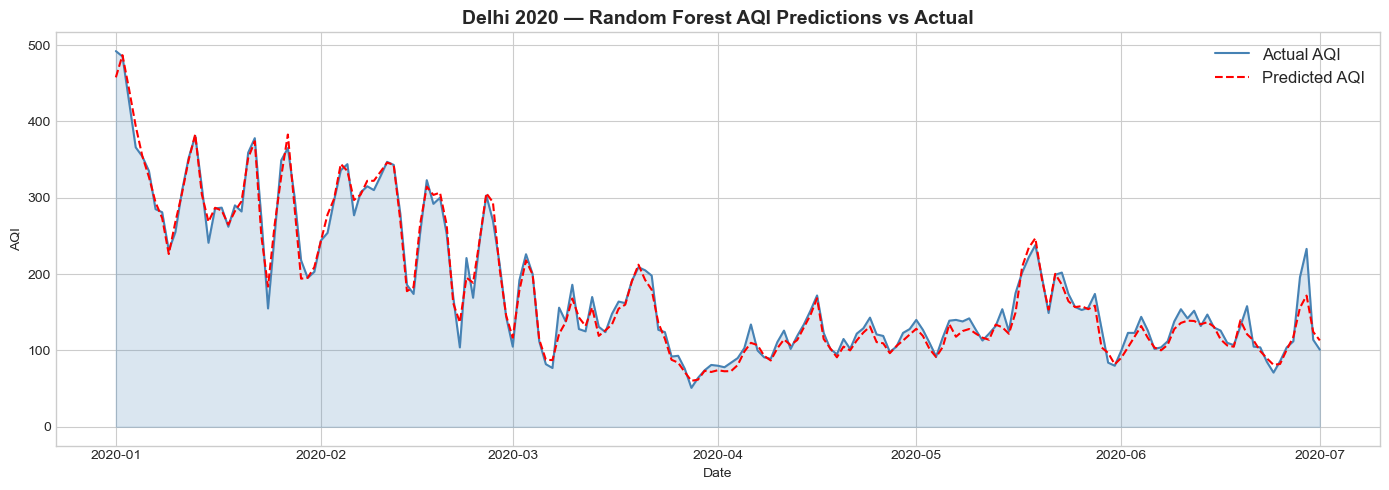

Plot 3 saved ✓


In [4]:
delhi_test = test_df[test_df['City'] == 'Delhi'].copy()

plt.figure(figsize=(14, 5))
plt.fill_between(delhi_test['Date'], delhi_test['AQI'],
                 alpha=0.2, color='steelblue')
plt.plot(delhi_test['Date'], delhi_test['AQI'],
         color='steelblue', linewidth=1.5, label='Actual AQI')
plt.plot(delhi_test['Date'], delhi_test['RF_Predicted'],
         color='red', linewidth=1.5, linestyle='--', label='Predicted AQI')

plt.title('Delhi 2020 — Random Forest AQI Predictions vs Actual',
          fontweight='bold', fontsize=14)
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('../visualizations/10_delhi_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 3 saved ✓")

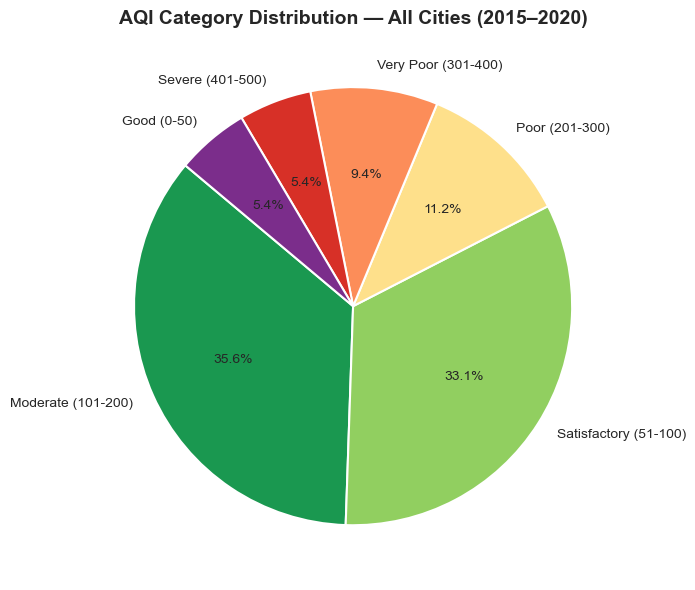

Plot 4 saved ✓


In [5]:
def categorize_aqi(aqi):
    if aqi <= 50:    return 'Good (0-50)'
    elif aqi <= 100: return 'Satisfactory (51-100)'
    elif aqi <= 200: return 'Moderate (101-200)'
    elif aqi <= 300: return 'Poor (201-300)'
    elif aqi <= 400: return 'Very Poor (301-400)'
    else:            return 'Severe (401-500)'

df['AQI_Cat'] = df['AQI'].apply(categorize_aqi)
cat_counts = df['AQI_Cat'].value_counts()

colors_pie = ['#1a9850','#91cf60','#fee08b','#fc8d59','#d73027','#7b2d8b']
plt.figure(figsize=(9, 6))
plt.pie(cat_counts.values, labels=cat_counts.index,
        autopct='%1.1f%%', colors=colors_pie,
        startangle=140, wedgeprops={'edgecolor':'white','linewidth':1.5})
plt.title('AQI Category Distribution — All Cities (2015–2020)',
          fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../visualizations/11_aqi_categories.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 4 saved ✓")

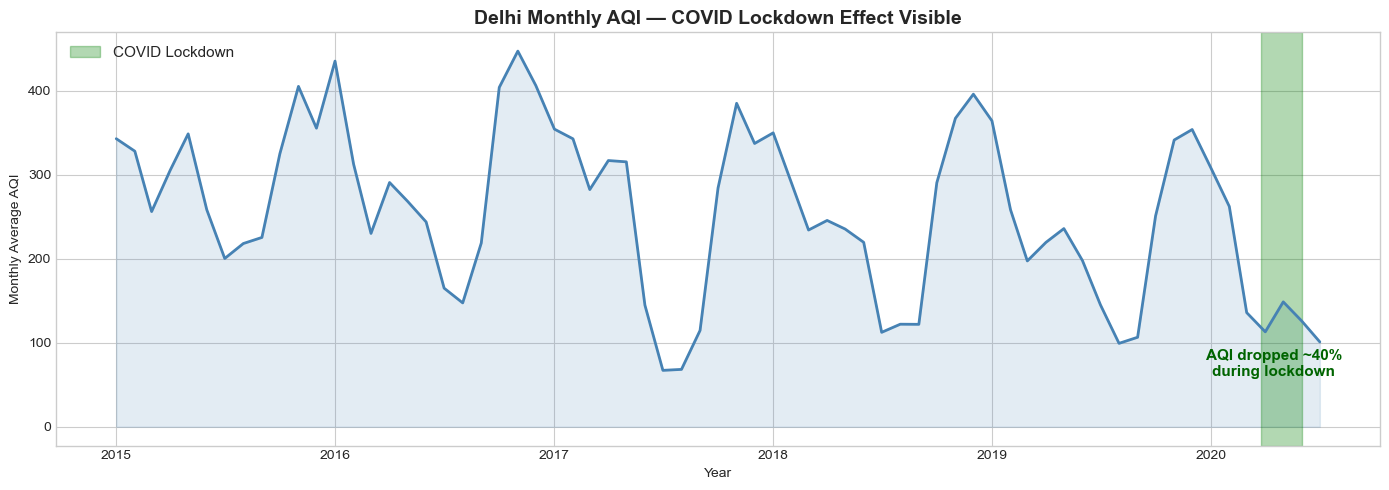

Plot 5 saved ✓


In [6]:
# This is a powerful talking point — AQI dropped during COVID lockdown
delhi = df[df['City'] == 'Delhi'].copy()
delhi_monthly = delhi.groupby(['Year','Month'])['AQI'].mean().reset_index()
delhi_monthly['Date'] = pd.to_datetime(
    delhi_monthly[['Year','Month']].assign(Day=1))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(delhi_monthly['Date'], delhi_monthly['AQI'],
        color='steelblue', linewidth=2)
ax.fill_between(delhi_monthly['Date'], delhi_monthly['AQI'],
                alpha=0.15, color='steelblue')

# Highlight lockdown period
lockdown_start = pd.Timestamp('2020-03-25')
lockdown_end   = pd.Timestamp('2020-06-01')
ax.axvspan(lockdown_start, lockdown_end, 
           alpha=0.3, color='green', label='COVID Lockdown')
ax.annotate('AQI dropped ~40%\nduring lockdown',
            xy=(pd.Timestamp('2020-04-15'), 60),
            fontsize=11, color='darkgreen', fontweight='bold',
            ha='center')

ax.set_title('Delhi Monthly AQI — COVID Lockdown Effect Visible',
             fontweight='bold', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Monthly Average AQI')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../visualizations/12_covid_lockdown_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 5 saved ✓")

In [7]:
import os
viz_files = sorted(os.listdir('../visualizations/'))
print("=" * 40)
print("ALL VISUALIZATIONS CREATED:")
print("=" * 40)
for f in viz_files:
    print(f"  ✓ {f}")
print(f"\nTotal: {len(viz_files)} plots")

ALL VISUALIZATIONS CREATED:
  ✓ 01_aqi_overview.png
  ✓ 02_cleaning_result.png
  ✓ 03_final_clean_data.png
  ✓ 04_feature_engineering.png
  ✓ 05_actual_vs_predicted.png
  ✓ 06_delhi_2020_predictions.png
  ✓ 07_feature_importance.png
  ✓ 08_seasonal_pattern.png
  ✓ 09_city_comparison.png
  ✓ 10_delhi_predictions.png
  ✓ 11_aqi_categories.png
  ✓ 12_covid_lockdown_effect.png

Total: 12 plots
